In [ ]:
!pip install kaggle

!mkdir -p ~/.kaggle

TOKEN = "KGAT_0782a2e658e8e2d67c052c108bf30d57"

with open("/root/.kaggle/access_token", "w") as f:
    f.write(TOKEN)

!chmod 600 ~/.kaggle/access_token

!kaggle competitions list

In [2]:
!kaggle datasets download -d thecarbyneuniverse/cats-vs-dogs --unzip

Dataset URL: https://www.kaggle.com/datasets/thecarbyneuniverse/cats-vs-dogs
License(s): unknown
100% 788M/788M [00:48<00:00, 17.0MB/s]



In [21]:
import tensorflow as tf
from tensorflow import  keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

Using Generators(Dividing the dataset to mini batches and work so that to fit in the RAM)

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    '/content/PetImages',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(256,256),
    batch_size=32
)

validation_ds = keras.utils.image_dataset_from_directory(
    '/content/PetImages',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(256,256),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [5]:
# for fixing errors Dynamically
train_ds = train_ds.apply(
    tf.data.experimental.ignore_errors()
)

validation_ds = validation_ds.apply(
    tf.data.experimental.ignore_errors()
)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Normalize

In [6]:
def process(image,label):
  image=tf.cast(image/255.,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

CNN model

In [22]:
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
    618/Unknown 61s 87ms/step - accuracy: 0.5360 - loss: 3.3259

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 69s 101ms/step - accuracy: 0.5484 - loss: 1.7289 - val_accuracy: 0.5821 - val_loss: 0.6718
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.5967 - loss: 0.6803 - val_accuracy: 0.6568 - val_loss: 0.6194
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.6590 - loss: 0.6169 - val_accuracy: 0.6991 - val_loss: 0.5711
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.7144 - loss: 0.5559 - val_accuracy: 0.7143 - val_loss: 0.5421
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7702 - loss: 0.4907 - val_accuracy: 0.7042 - val_loss: 0.5401
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.8018 - loss: 0.4346 - val_accuracy: 0.7962 - val_loss: 0.4758
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 92s 149ms/step - accuracy: 0.8352 - loss: 0.3763 - val_accuracy: 0.7079 - val_loss: 0.6109
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.8574 - loss: 0.3265 - val_accur

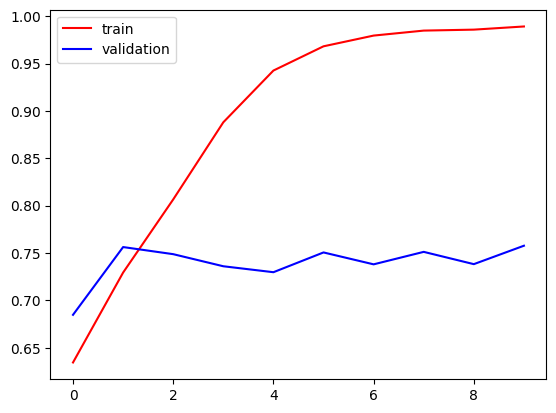

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

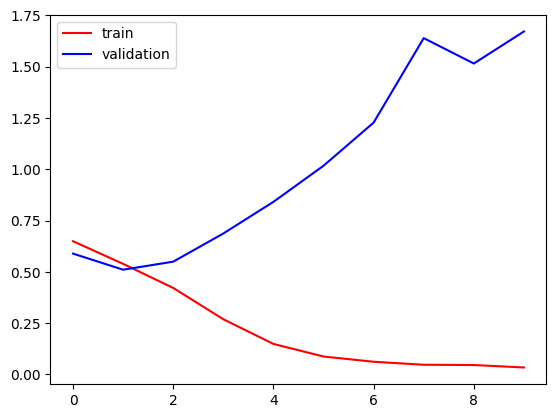

In [18]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [20]:
# U can see the above model is suffering from overfitting , u can reduce it by

# Add more data
# Data Augmentation
# L1/L2 Regularizer
# Dropout
# BatchNorm
# Reduce the Complexity

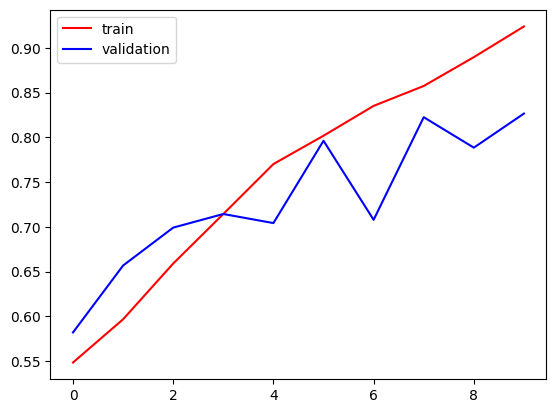

In [26]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

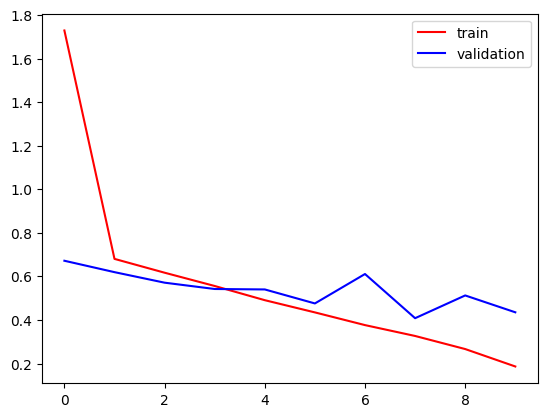

In [27]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()